Importing all needed imports

In [6]:
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import pickle
import numpy as np

In [7]:
path = kagglehub.dataset_download("adilshamim8/education-and-career-success")
print("Path to dataset files:", path)

Path to dataset files: /home/jonathan/.cache/kagglehub/datasets/adilshamim8/education-and-career-success/versions/3


In [8]:
df = pd.read_csv(path + '/education_career_success.csv')
df.head()

,Student_ID,Age,Gender,High_School_GPA,SAT_Score,University_GPA,Field_of_Study,Internships_Completed,Projects_Completed,Certifications,Soft_Skills_Score,Networking_Score,Job_Offers,Starting_Salary,Career_Satisfaction,Years_to_Promotion,Current_Job_Level,Work_Life_Balance,Entrepreneurship
0,S001,22,Male,3.8,1450,3.6,Computer Science,3,7,2,8,7,3,85000,8,2,Mid,7,No
1,S002,24,Female,3.6,1380,3.4,Business,2,5,3,7,6,2,65000,7,3,Mid,6,No
2,S003,21,Male,3.9,1520,3.8,Engineering,4,9,4,9,8,4,120000,9,1,Senior,6,No
3,S004,23,Female,3.5,1300,3.2,Psychology,1,3,1,6,5,1,48000,6,4,Entry,8,No
4,S005,25,Male,3.7,1420,3.5,Medicine,2,6,2,8,7,3,95000,8,2,Mid,5,No


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             400 non-null    str    
 1   Age                    400 non-null    int64  
 2   Gender                 400 non-null    str    
 3   High_School_GPA        400 non-null    float64
 4   SAT_Score              400 non-null    int64  
 5   University_GPA         400 non-null    float64
 6   Field_of_Study         400 non-null    str    
 7   Internships_Completed  400 non-null    int64  
 8   Projects_Completed     400 non-null    int64  
 9   Certifications         400 non-null    int64  
 10  Soft_Skills_Score      400 non-null    int64  
 11  Networking_Score       400 non-null    int64  
 12  Job_Offers             400 non-null    int64  
 13  Starting_Salary        400 non-null    int64  
 14  Career_Satisfaction    400 non-null    int64  
 15  Years_to_Promotio

Removing the features that doesn't contribute to the Model we are building          

In [10]:
columns_to_drop = [
    'Student_ID',          
    'Starting_Salary',      
    'Career_Satisfaction',  
    'Years_to_Promotion',   
    'Current_Job_Level',    
    'Work_Life_Balance',    
    'Entrepreneurship'      
]
df = df.drop(columns=columns_to_drop)
df.head()

,Age,Gender,High_School_GPA,SAT_Score,University_GPA,Field_of_Study,Internships_Completed,Projects_Completed,Certifications,Soft_Skills_Score,Networking_Score,Job_Offers
0,22,Male,3.8,1450,3.6,Computer Science,3,7,2,8,7,3
1,24,Female,3.6,1380,3.4,Business,2,5,3,7,6,2
2,21,Male,3.9,1520,3.8,Engineering,4,9,4,9,8,4
3,23,Female,3.5,1300,3.2,Psychology,1,3,1,6,5,1
4,25,Male,3.7,1420,3.5,Medicine,2,6,2,8,7,3


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    400 non-null    int64  
 1   Gender                 400 non-null    str    
 2   High_School_GPA        400 non-null    float64
 3   SAT_Score              400 non-null    int64  
 4   University_GPA         400 non-null    float64
 5   Field_of_Study         400 non-null    str    
 6   Internships_Completed  400 non-null    int64  
 7   Projects_Completed     400 non-null    int64  
 8   Certifications         400 non-null    int64  
 9   Soft_Skills_Score      400 non-null    int64  
 10  Networking_Score       400 non-null    int64  
 11  Job_Offers             400 non-null    int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 37.6 KB


Ploting a Histogram

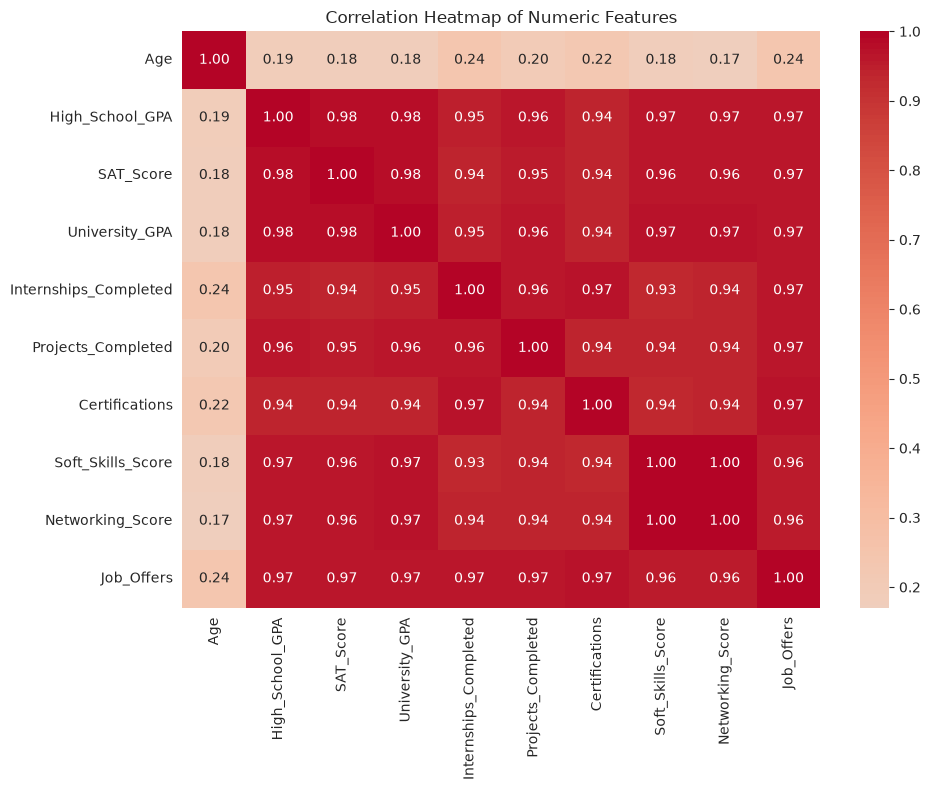

In [12]:
sns.set_style("whitegrid")
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(10, 8))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.savefig("plotImages/correlation_heatmap.png", dpi=150)
plt.show()

According to this heatmap:
age is completely irrelevant it's correlation is between 0.17 and 0.24 with all other features which means a weak correlation and other thing that is worth meantioning is that all other features are highly correlated but 2 features(soft_skills_scrore and Networking_Score) correlates at one and that is very strong correlation(multicollinearity).

Histogram

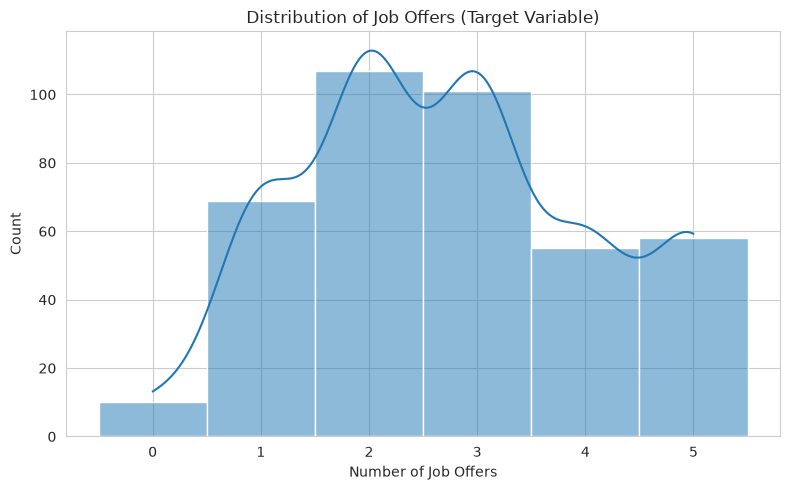

Job_Offers
0     10
1     69
2    107
3    101
4     55
5     58
Name: count, dtype: int64


In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Job_Offers'], bins=6, kde=True, discrete=True)
plt.title("Distribution of Job Offers (Target Variable)")
plt.xlabel("Number of Job Offers")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("plotImages/Histogram_JobOffers.png", dpi=150)
plt.show()
print(df['Job_Offers'].value_counts().sort_index())

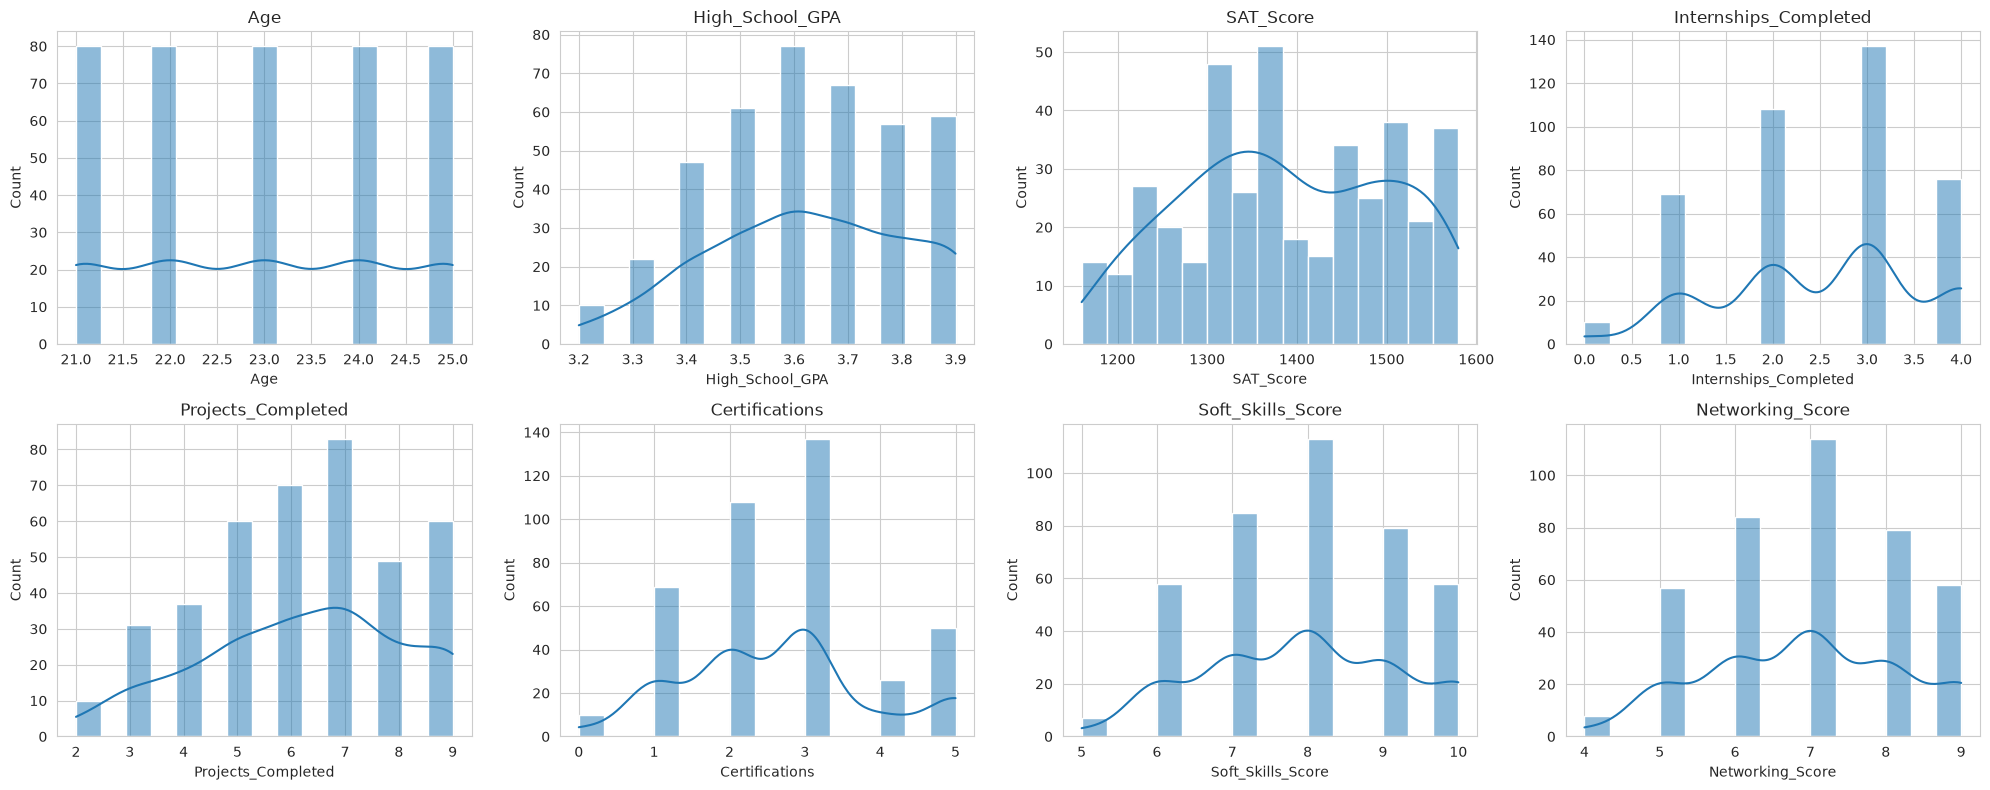

In [14]:
predictors_histogram = ['Age', 'High_School_GPA', 'SAT_Score', 
                         'Internships_Completed', 'Projects_Completed', 
                         'Certifications', 'Soft_Skills_Score', 'Networking_Score']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, col in zip(axes.flatten(), predictors_histogram):
    sns.histplot(df[col], bins=15, kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig("plotImages/FeaturesHistogram.png", dpi=150)
plt.show()

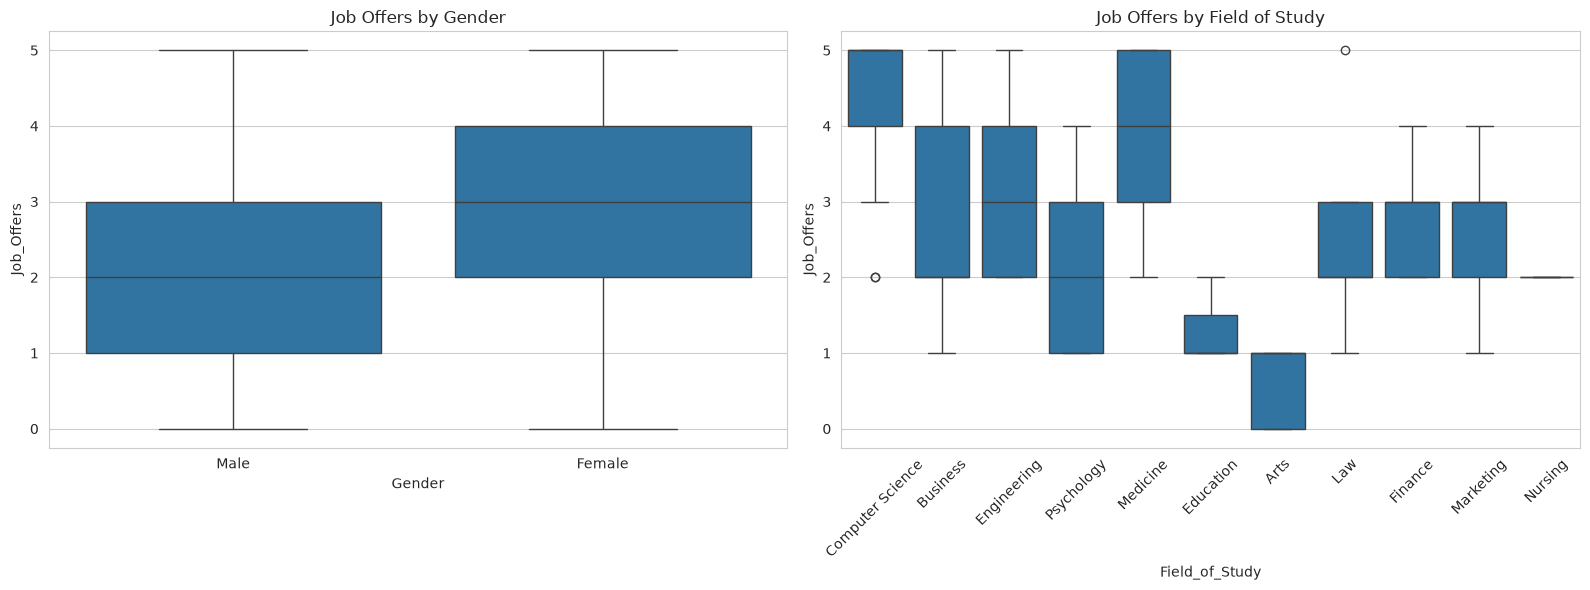

Gender
Female    3.055
Male      2.425
Name: Job_Offers, dtype: float64
Field_of_Study
Arts                0.687500
Business            2.555556
Computer Science    4.551020
Education           1.333333
Engineering         2.982759
Finance             2.800000
Law                 2.409091
Marketing           2.613636
Medicine            4.085714
Nursing             2.000000
Psychology          1.927273
Name: Job_Offers, dtype: float64


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x='Gender', y='Job_Offers', ax=axes[0])
axes[0].set_title('Job Offers by Gender')

sns.boxplot(data=df, x='Field_of_Study', y='Job_Offers', ax=axes[1])
axes[1].set_title('Job Offers by Field of Study')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("plotImages/categorical_vs_target.png", dpi=150)
plt.show()

# Also useful: mean Job_Offers per category
print(df.groupby('Gender')['Job_Offers'].mean())
print(df.groupby('Field_of_Study')['Job_Offers'].mean())

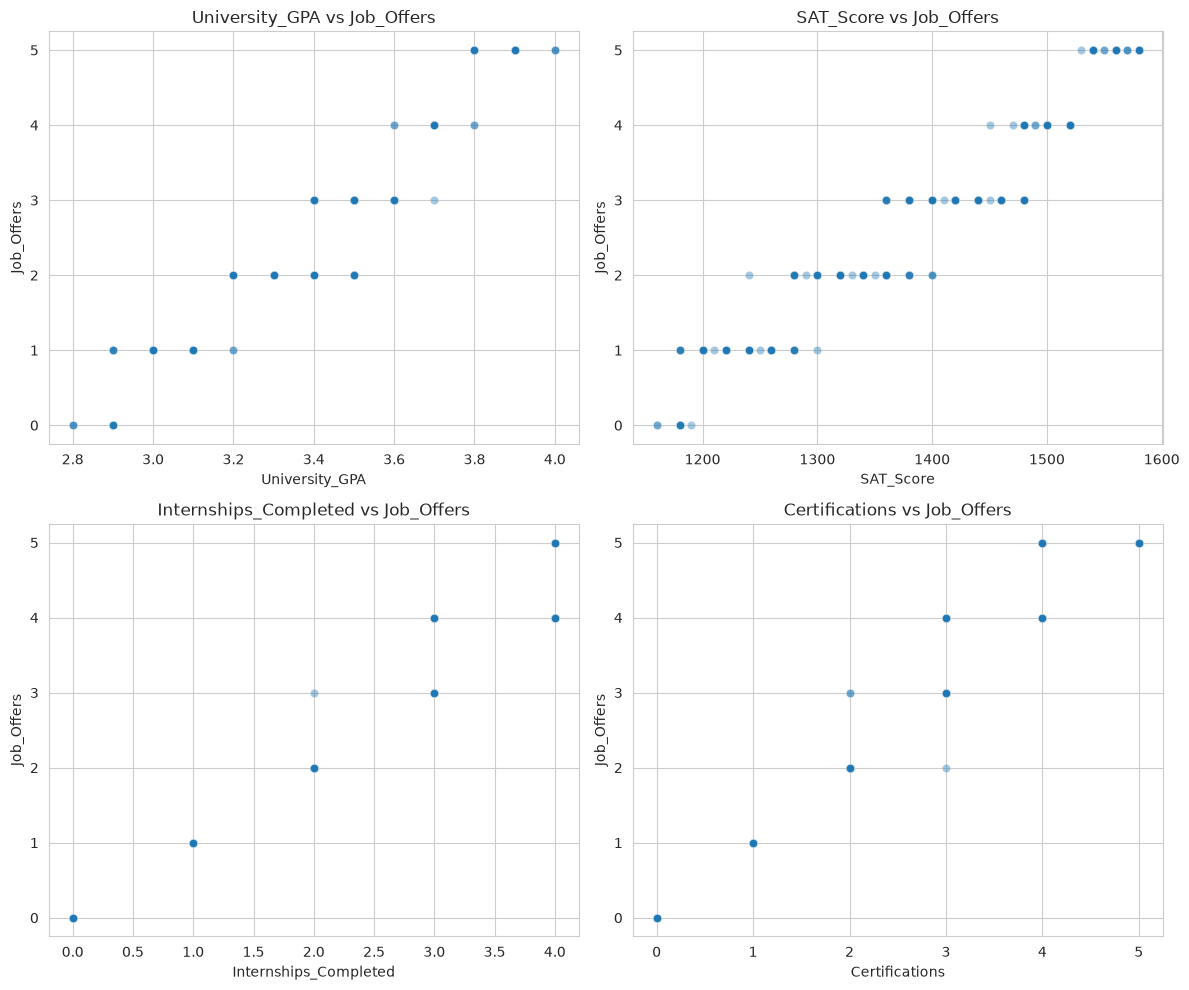

In [16]:
top_predictors = ['University_GPA', 'SAT_Score', 'Internships_Completed', 'Certifications']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, col in zip(axes.flatten(), top_predictors):
    sns.scatterplot(x=df[col], y=df['Job_Offers'], alpha=0.4, ax=ax)
    ax.set_title(f"{col} vs Job_Offers")
plt.tight_layout()
plt.savefig("plotImages/scatter_vs_target.png", dpi=150)
plt.show()

In [17]:

df = df.drop(columns=['Age', 'Networking_Score'])
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})


Age and Networking_Score were dropped because Age showed that it contribute a little to Job_Offers and Networking_Score was perfectly correlated with Soft_Skills_Score making it redundant. another thing is gender was binary-encoded (Male=0, Female=1) since it has only two categories.

In [18]:
df = pd.get_dummies(df, columns=['Field_of_Study'], drop_first=True)


I used get_dummies to convert field of studies datas into numerical binary variables 0s and 1s. 

In [19]:
df.columns

Index(['Gender', 'High_School_GPA', 'SAT_Score', 'University_GPA',
       'Internships_Completed', 'Projects_Completed', 'Certifications',
       'Soft_Skills_Score', 'Job_Offers', 'Field_of_Study_Business',
       'Field_of_Study_Computer Science', 'Field_of_Study_Education',
       'Field_of_Study_Engineering', 'Field_of_Study_Finance',
       'Field_of_Study_Law', 'Field_of_Study_Marketing',
       'Field_of_Study_Medicine', 'Field_of_Study_Nursing',
       'Field_of_Study_Psychology'],
      dtype='str')

In [20]:
df.head()

,Gender,High_School_GPA,SAT_Score,University_GPA,Internships_Completed,Projects_Completed,Certifications,Soft_Skills_Score,Job_Offers,Field_of_Study_Business,Field_of_Study_Computer Science,Field_of_Study_Education,Field_of_Study_Engineering,Field_of_Study_Finance,Field_of_Study_Law,Field_of_Study_Marketing,Field_of_Study_Medicine,Field_of_Study_Nursing,Field_of_Study_Psychology
0,0,3.8,1450,3.6,3,7,2,8,3,False,True,False,False,False,False,False,False,False,False
1,1,3.6,1380,3.4,2,5,3,7,2,True,False,False,False,False,False,False,False,False,False
2,0,3.9,1520,3.8,4,9,4,9,4,False,False,False,True,False,False,False,False,False,False
3,1,3.5,1300,3.2,1,3,1,6,1,False,False,False,False,False,False,False,False,False,True
4,0,3.7,1420,3.5,2,6,2,8,3,False,False,False,False,False,False,False,True,False,False


In [21]:
X = df.drop(columns=['Job_Offers'])
y = df['Job_Offers']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Splited the features for one that we will use in training of the model and the other one that we will use in training. and another thing we did is we scaled our data because our X has has variables with very different ranges and if we don't scale these numbers, the model might assume that the larger numbers are inherently more important.

In [22]:
lin_model = LinearRegression()
sgd_model = SGDRegressor(random_state=42, max_iter=1000, tol=1e-3)
tree_model = DecisionTreeRegressor(random_state=42)
forest_model = RandomForestRegressor(random_state=42, n_estimators=100)


lin_model.fit(X_train_scaled, y_train)
sgd_model.fit(X_train_scaled, y_train)
tree_model.fit(X_train_scaled, y_train)
forest_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

Training all 4 models on the already scailed train data

In [23]:
def evaluate(name, model, X_test, y_test):
    pred = model.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    return {'Model': name, 'MSE': mse, 'RMSE': np.sqrt(mse)}

results_df = pd.DataFrame([
    evaluate('LinearRegression', lin_model, X_test_scaled, y_test),
    evaluate('SGDRegressor', sgd_model, X_test_scaled, y_test),
    evaluate('DecisionTreeRegressor', tree_model, X_test_scaled, y_test),
    evaluate('RandomForestRegressor', forest_model, X_test_scaled, y_test),
]).set_index('Model').sort_values('RMSE')

results_df

,MSE,RMSE
Model,,
RandomForestRegressor,0.004562,0.067546
DecisionTreeRegressor,0.012500,0.111803
LinearRegression,0.036998,0.192349
SGDRegressor,0.039739,0.199346


According to this results you canse that Random Forest Regressor is the good performing one

In [26]:
with open('model/reg_model.pkl', 'wb') as file:
    pickle.dump(forest_model, file)

I now saved the forest model in model directory


In [28]:
with open('model/scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

I also exported my scaller because I will be needing it to transform the inputs before predicting them otherwise predictions will be wrong.